# Internal Notifications API — R notebook

This notebook follows the same practical style used by the public InfoDengue service tutorials: configure the API endpoint, build a reusable request function, query with parameters, convert results to a data frame, and run simple analyses.

Before running, set:

```bash
export NOTIFICATION_API_TOKEN="your-token"
export NOTIFICATION_API_BASE_URL="http://s2.dengue.mat.br"
```


In [1]:
library(httr2)
library(jsonlite)
library(dplyr)
library(tidyr)
library(ggplot2)
library(lubridate)
library(glue)



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘lubridate’


The following objects are masked from ‘package:base’:

    date, intersect, setdiff, union




## 1. API configuration

In [3]:
api_base_url <- Sys.getenv("NOTIFICATION_API_BASE_URL", "http://s2.dengue.mat.br")
api_token <- Sys.getenv("NOTIFICATION_API_TOKEN")

if (identical(api_token, "")) {
  stop("Set NOTIFICATION_API_TOKEN before running this notebook.")
}

notifications_url <- file.path(api_base_url, "api", "internal", "notifications")
notifications_url


[1] "http://s2.dengue.mat.br/api/internal/notifications"

## 2. Request helper

In [4]:
compact_params <- function(params) {
  params[!vapply(params, is.null, logical(1))]
}

get_notifications <- function(
  municipio_geocodigo = NULL,
  cid10 = NULL,
  year = NULL,
  epiweek_start = NULL,
  epiweek_end = NULL,
  date_start = NULL,
  date_end = NULL,
  limit = 1000,
  offset = 0,
  include_count = FALSE
) {
  params <- compact_params(list(
    municipio_geocodigo = municipio_geocodigo,
    cid10 = cid10,
    year = year,
    epiweek_start = epiweek_start,
    epiweek_end = epiweek_end,
    date_start = date_start,
    date_end = date_end,
    limit = limit,
    offset = offset,
    include_count = tolower(as.character(include_count))
  ))

  request(notifications_url) |>
    req_headers(
      Authorization = glue("Token {api_token}"),
      Accept = "application/json"
    ) |>
    req_url_query(!!!params) |>
    req_timeout(30) |>
    req_perform() |>
    resp_body_json(simplifyVector = TRUE)
}

notifications_to_tibble <- function(payload) {
  if (length(payload$results) == 0) {
    return(tibble())
  }

  as_tibble(payload$results) |>
    mutate(
      across(
        any_of(c("dt_notific", "dt_sin_pri", "dt_digita")),
        ~ as.Date(.x)
      )
    )
}


## 3. Basic request: dengue notifications for Rio de Janeiro

In [5]:
payload <- get_notifications(
  municipio_geocodigo = 3304557,
  cid10 = "A90",
  year = 2025,
  limit = 10,
  offset = 0
)

notifications <- notifications_to_tibble(payload)
notifications


id,municipio_geocodigo,dt_notific,dt_sin_pri,dt_digita,se_notif,ano_notif,classi_fin,criterio,cid10_codigo,id_distrit,id_bairro,nm_bairro,nu_notific
<int>,<int>,<date>,<date>,<date>,<int>,<int>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<int>
1524117162,3304557,2026-01-03,2025-12-30,2026-01-19,53,2025,5,2,A90,138,118,CIDADE DE DEUS,6426846
1521769543,3304557,2026-01-03,2026-01-01,2026-01-05,53,2025,5,1,A90,136,74,VILA DA PENHA,6417545
1521747253,3304557,2026-01-03,2026-01-03,2026-01-06,53,2025,5,1,A90,132,0,RAMOS,6610617
1521563281,3304557,2026-01-03,2025-12-25,2026-01-08,53,2025,5,1,A90,148,152,BARRA DE GUARATIBA,6529897
1521441356,3304557,2026-01-03,2026-01-01,2026-01-13,53,2025,10,2,A90,125,6,CATUMBI,2299693
1521079529,3304557,2026-01-03,2026-01-01,2026-01-07,53,2025,5,1,A90,134,51,JACARE,6612215
1514752519,3304557,2026-01-03,2025-12-15,2026-01-03,53,2025,5,1,A90,140,144,CAMPO GRANDE,6613489
1514727713,3304557,2026-01-03,2026-01-01,2026-01-03,53,2025,10,1,A90,139,141,BANGU,6605423
1540822783,3304557,2026-01-02,2025-12-30,2026-02-03,53,2025,5,1,A90,130,33,TIJUCA,6527900


## 4. Request total count only when needed

In [6]:
payload_with_count <- get_notifications(
  municipio_geocodigo = 3304557,
  cid10 = "A90",
  year = 2025,
  limit = 10,
  offset = 0,
  include_count = TRUE
)

payload_with_count$count


[1] 31205

## 5. Fetch multiple pages safely

In [7]:
get_notification_pages <- function(
  page_size = 1000,
  max_rows = 5000,
  ...
) {
  offsets <- seq(0, max_rows - page_size, by = page_size)
  pages <- list()

  for (offset in offsets) {
    payload <- get_notifications(
      ...,
      limit = page_size,
      offset = offset
    )

    page <- notifications_to_tibble(payload)

    if (nrow(page) == 0) {
      break
    }

    pages[[length(pages) + 1]] <- page

    if (nrow(page) < page_size) {
      break
    }
  }

  if (length(pages) == 0) {
    return(tibble())
  }

  bind_rows(pages)
}

notifications_pages <- get_notification_pages(
  municipio_geocodigo = 3304557,
  cid10 = "A90",
  year = 2025,
  page_size = 500,
  max_rows = 2000
)

dim(notifications_pages)


[1] 2000   14

## 6. Simple analyses

In [8]:
notifications_pages |>
  summarise(
    rows = n(),
    date_min = min(dt_notific, na.rm = TRUE),
    date_max = max(dt_notific, na.rm = TRUE),
    unique_neighborhoods = n_distinct(nm_bairro, na.rm = TRUE),
    unique_epiweeks = n_distinct(se_notif, na.rm = TRUE)
  )


rows,date_min,date_max,unique_neighborhoods,unique_epiweeks
<int>,<date>,<date>,<int>,<int>
2000,2025-10-31,2026-01-03,195,10


In [9]:
by_epiweek <- notifications_pages |>
  count(se_notif, name = "notifications") |>
  arrange(se_notif)

by_epiweek


se_notif,notifications
<int>,<int>
44,14
45,234
46,259
47,228
48,252
49,249
50,254
51,230
52,113


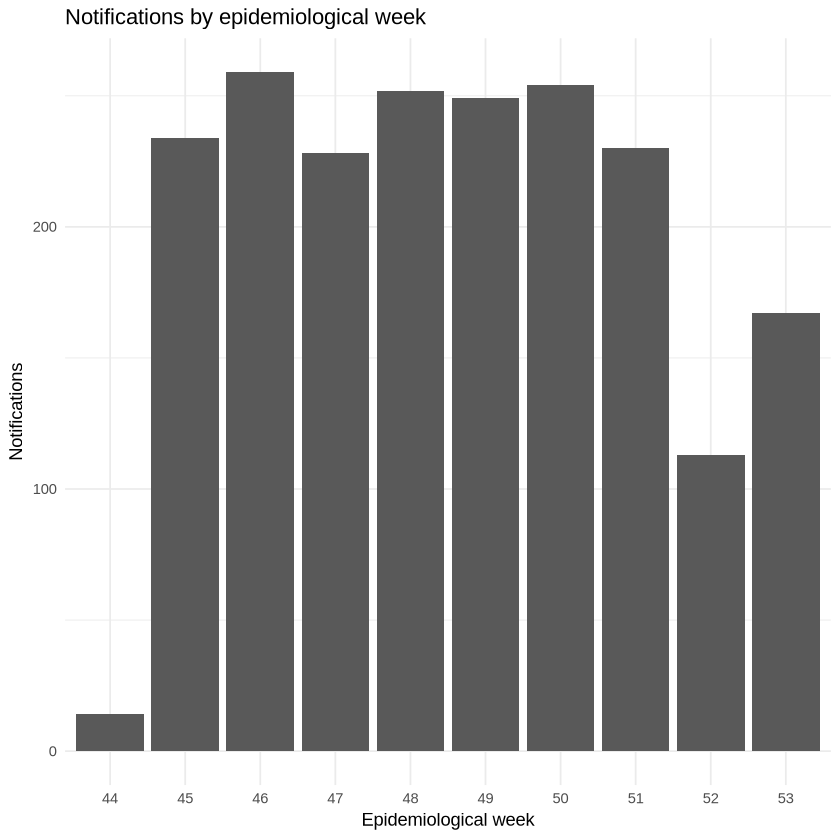

In [10]:
ggplot(by_epiweek, aes(x = factor(se_notif), y = notifications)) +
  geom_col() +
  labs(
    title = "Notifications by epidemiological week",
    x = "Epidemiological week",
    y = "Notifications"
  ) +
  theme_minimal()


In [11]:
top_neighborhoods <- notifications_pages |>
  mutate(nm_bairro = replace_na(nm_bairro, "Unknown")) |>
  count(nm_bairro, name = "notifications", sort = TRUE) |>
  slice_head(n = 15)

top_neighborhoods


nm_bairro,notifications
<chr>,<int>
SANTA CRUZ,132
GUARATIBA,109
CAMPO GRANDE,105
TIJUCA,67
BANGU,65
BENFICA,53
RAMOS,40
INHOAIBA,39
JACAREPAGUA,35


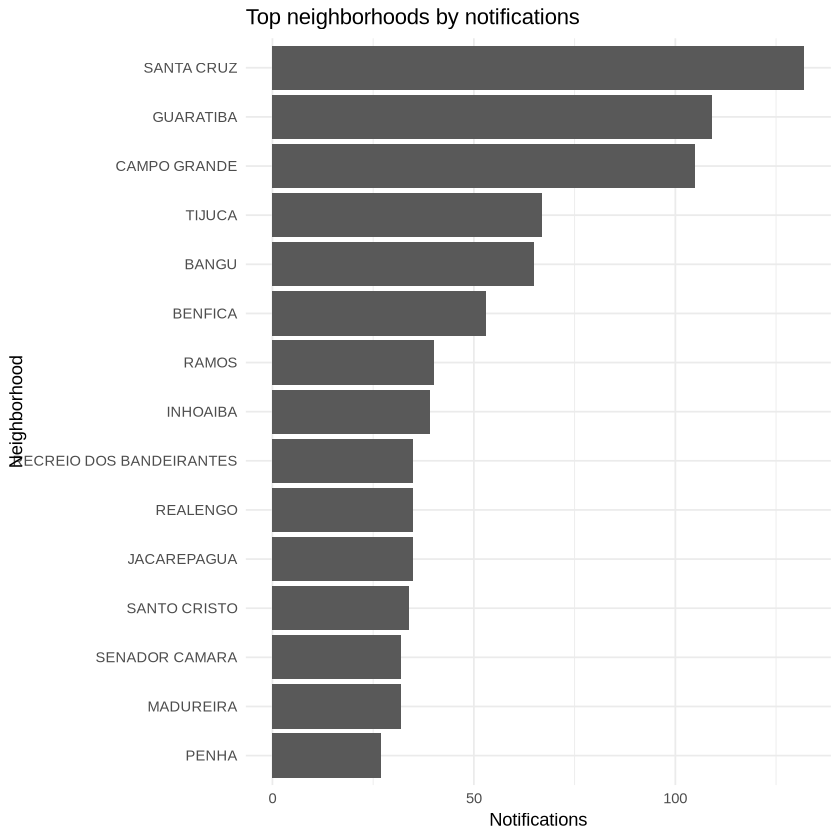

In [12]:
ggplot(top_neighborhoods, aes(x = reorder(nm_bairro, notifications), y = notifications)) +
  geom_col() +
  coord_flip() +
  labs(
    title = "Top neighborhoods by notifications",
    x = "Neighborhood",
    y = "Notifications"
  ) +
  theme_minimal()


## 7. Compare diseases or years

In [14]:
comparison <- bind_rows(lapply(c("A90", "A92"), function(disease) {
  get_notification_pages(
    municipio_geocodigo = 3304557,
    cid10 = disease,
    year = 2025,
    page_size = 500,
    max_rows = 1000
  ) |>
    mutate(requested_cid10 = disease)
}))

comparison |>
  count(requested_cid10, se_notif, name = "notifications") |>
  arrange(requested_cid10, se_notif)


requested_cid10,se_notif,notifications
<chr>,<int>,<int>
A90,49,236
A90,50,254
A90,51,230
A90,52,113
A90,53,167


## 8. Notes

- Keep page sizes conservative during exploration.
- Use `include_count = TRUE` only when the total number of matching rows is needed.
- Do not commit real tokens to the repository.
